In [11]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


Total training images : 60000
Number of batches     : 469


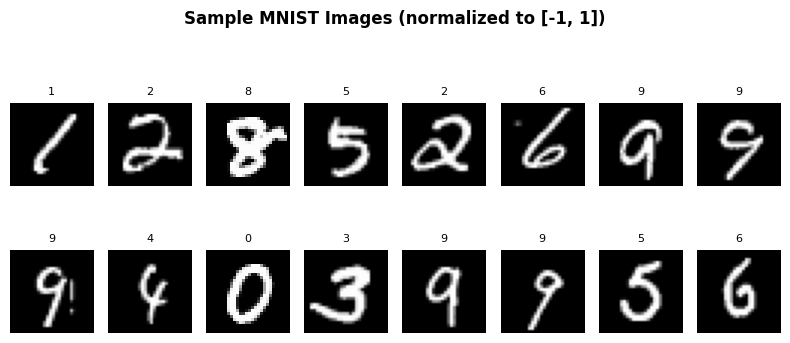

In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

print(f'Total training images : {len(train_dataset)}')
print(f'Number of batches     : {len(train_loader)}')

images, labels = next(iter(train_loader))

plt.figure(figsize=(8, 4))
plt.suptitle('Sample MNIST Images (normalized to [-1, 1])', fontsize=12, fontweight='bold')
for i in range(16):
    plt.subplot(2, 8, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap='gray')
    plt.title(labels[i].item(), fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [13]:
LATENT_DIM = 100
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256, momentum=0.8),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512, momentum=0.8),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024, momentum=0.8),

            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 1, 28, 28)
        return img

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

generator = Generator(LATENT_DIM).to(DEVICE)
discriminator = Discriminator().to(DEVICE)

g_params = sum(p.numel() for p in generator.parameters())
d_params = sum(p.numel() for p in discriminator.parameters())
print(f'Generator parameters     : {g_params:,}')
print(f'Discriminator parameters : {d_params:,}')

Generator parameters     : 1,489,936
Discriminator parameters : 533,505


In [14]:
criterion   = nn.BCELoss()

optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

NUM_EPOCHS = 50
fixed_noise = torch.randn(16, LATENT_DIM, device=DEVICE)

print('Setup complete. Starting training for', NUM_EPOCHS, 'epochs.')

Setup complete. Starting training for 50 epochs.


In [15]:
G_losses = []
D_losses = []
D_real_accs = []
D_fake_accs = []

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_G_loss = 0.0
    epoch_D_loss = 0.0
    epoch_real_acc = 0.0
    epoch_fake_acc = 0.0
    num_batches = 0

    for real_images, _ in train_loader:
        batch_size = real_images.size(0)
        real_images = real_images.to(DEVICE)

        real_labels = torch.ones(batch_size, 1, device=DEVICE)
        fake_labels = torch.zeros(batch_size, 1, device=DEVICE)

        optimizer_D.zero_grad()
        output_real = discriminator(real_images)
        loss_D_real = criterion(output_real, real_labels)

        z = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
        fake_images = generator(z).detach()
        output_fake = discriminator(fake_images)
        loss_D_fake = criterion(output_fake, fake_labels)

        loss_D = (loss_D_real + loss_D_fake) / 2
        loss_D.backward()
        optimizer_D.step()

        optimizer_G.zero_grad()

        z = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
        gen_images = generator(z)
        output_gen = discriminator(gen_images)

        loss_G = criterion(output_gen, torch.ones(batch_size, 1, device=DEVICE))
        loss_G.backward()
        optimizer_G.step()

        epoch_G_loss   += loss_G.item()
        epoch_D_loss   += loss_D.item()
        epoch_real_acc += (output_real > 0.5).float().mean().item()
        epoch_fake_acc += (output_fake < 0.5).float().mean().item()
        num_batches    += 1

    avg_G  = epoch_G_loss   / num_batches
    avg_D  = epoch_D_loss   / num_batches
    avg_ra = epoch_real_acc / num_batches
    avg_fa = epoch_fake_acc / num_batches

    G_losses.append(avg_G)
    D_losses.append(avg_D)
    D_real_accs.append(avg_ra)
    D_fake_accs.append(avg_fa)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch [{epoch:3d}/{NUM_EPOCHS}]  '
              f'D_loss: {avg_D:.4f}  G_loss: {avg_G:.4f}  '
              f'D(real): {avg_ra:.3f}  D(fake): {avg_fa:.3f}')

print('\nTraining complete!')

Epoch [  1/50]  D_loss: 0.4192  G_loss: 1.1648  D(real): 0.908  D(fake): 0.707
Epoch [  5/50]  D_loss: 0.6448  G_loss: 0.8241  D(real): 0.613  D(fake): 0.637
Epoch [ 10/50]  D_loss: 0.6709  G_loss: 0.7616  D(real): 0.565  D(fake): 0.605
Epoch [ 15/50]  D_loss: 0.6799  G_loss: 0.7415  D(real): 0.546  D(fake): 0.589
Epoch [ 20/50]  D_loss: 0.6826  G_loss: 0.7366  D(real): 0.532  D(fake): 0.584
Epoch [ 25/50]  D_loss: 0.6838  G_loss: 0.7324  D(real): 0.532  D(fake): 0.577
Epoch [ 30/50]  D_loss: 0.6851  G_loss: 0.7272  D(real): 0.527  D(fake): 0.573
Epoch [ 35/50]  D_loss: 0.6854  G_loss: 0.7268  D(real): 0.529  D(fake): 0.571
Epoch [ 40/50]  D_loss: 0.6850  G_loss: 0.7257  D(real): 0.529  D(fake): 0.568
Epoch [ 45/50]  D_loss: 0.6863  G_loss: 0.7245  D(real): 0.525  D(fake): 0.564
Epoch [ 50/50]  D_loss: 0.6853  G_loss: 0.7235  D(real): 0.529  D(fake): 0.567

Training complete!


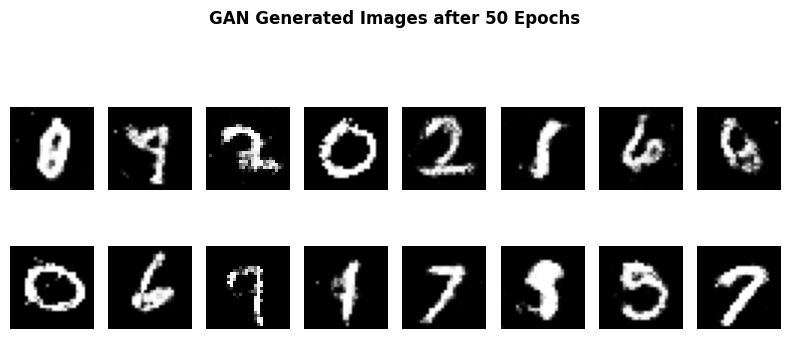

In [16]:
generator.eval()

with torch.no_grad():
    z = torch.randn(16, LATENT_DIM, device=DEVICE)
    generated_images = generator(z).cpu()

plt.figure(figsize=(8, 4))
plt.suptitle(f'GAN Generated Images after {NUM_EPOCHS} Epochs', fontsize=12, fontweight='bold')
for i in range(16):
    plt.subplot(2, 8, i + 1)
    plt.imshow(generated_images[i].squeeze().numpy(), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

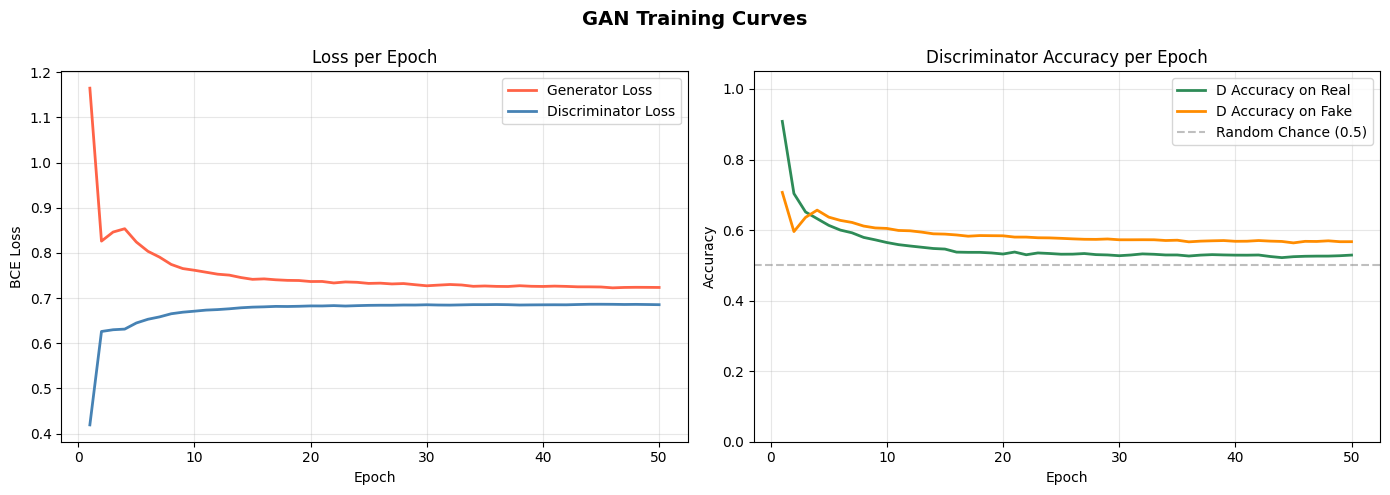

Final Generator Loss     : 0.7235
Final Discriminator Loss : 0.6853
D Accuracy on Real       : 0.529
D Accuracy on Fake       : 0.567


In [17]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GAN Training Curves', fontsize=14, fontweight='bold')

ax1.plot(epochs_range, G_losses, label='Generator Loss',     color='tomato',     linewidth=2)
ax1.plot(epochs_range, D_losses, label='Discriminator Loss', color='steelblue',  linewidth=2)
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, D_real_accs, label='D Accuracy on Real', color='seagreen',  linewidth=2)
ax2.plot(epochs_range, D_fake_accs, label='D Accuracy on Fake', color='darkorange', linewidth=2)
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random Chance (0.5)')
ax2.set_title('Discriminator Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final Generator Loss     : {G_losses[-1]:.4f}')
print(f'Final Discriminator Loss : {D_losses[-1]:.4f}')
print(f'D Accuracy on Real       : {D_real_accs[-1]:.3f}')
print(f'D Accuracy on Fake       : {D_fake_accs[-1]:.3f}')

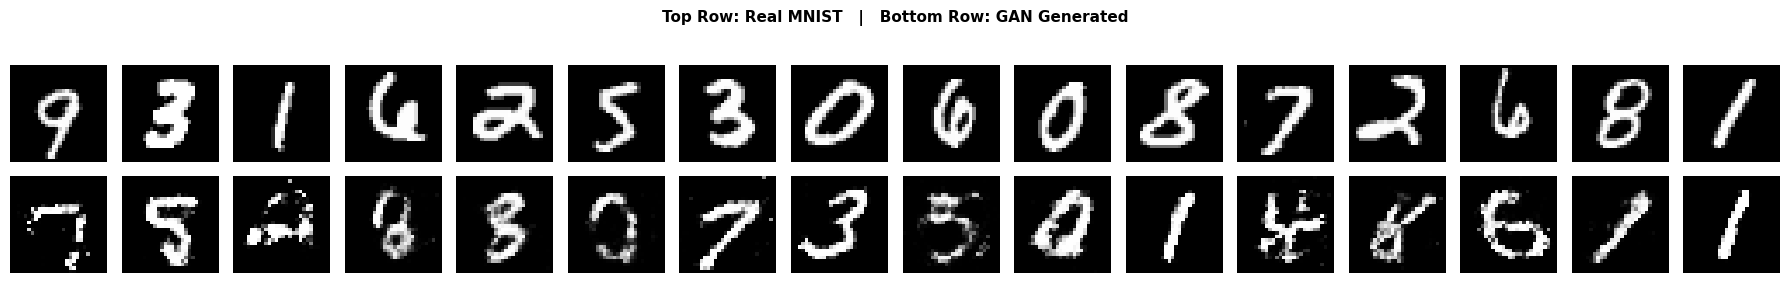

In [18]:
real_sample, _ = next(iter(train_loader))

generator.eval()
with torch.no_grad():
    z    = torch.randn(16, LATENT_DIM, device=DEVICE)
    fake = generator(z).cpu()

fig, axes = plt.subplots(2, 16, figsize=(18, 3))
fig.suptitle('Top Row: Real MNIST   |   Bottom Row: GAN Generated', fontsize=11, fontweight='bold')

for i in range(16):
    axes[0, i].imshow(real_sample[i].squeeze().numpy(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(fake[i].squeeze().numpy(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Real',      fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Generated', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()